In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# BRI

In [2]:
ticker = "BBRI.JK"
start_date = "2021-12-31"
end_date = "2023-12-18"

data = yf.download(ticker, start=start_date, end=end_date)

print(data)

[*********************100%%**********************]  1 of 1 completed
              Open    High     Low   Close    Adj Close     Volume
Date                                                              
2022-01-03  4120.0  4190.0  4090.0  4180.0  3783.320312   90842500
2022-01-04  4200.0  4210.0  4160.0  4160.0  3765.218506   93950000
2022-01-05  4180.0  4230.0  4130.0  4210.0  3810.473389  174376400
2022-01-06  4240.0  4240.0  4140.0  4160.0  3765.218506  137280000
2022-01-07  4170.0  4200.0  4150.0  4190.0  3792.371338  101275000
...            ...     ...     ...     ...          ...        ...
2023-12-11  5325.0  5375.0  5300.0  5300.0  5300.000000  124468600
2023-12-12  5375.0  5400.0  5325.0  5325.0  5325.000000  134501600
2023-12-13  5300.0  5350.0  5275.0  5300.0  5300.000000   98881600
2023-12-14  5450.0  5550.0  5425.0  5550.0  5550.000000  239261700
2023-12-15  5575.0  5600.0  5550.0  5550.0  5550.000000  252448800

[477 rows x 6 columns]


# Model




In [3]:
import math
import numpy as np



# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [15]:
x_test[:5]

array([[[0.82758621],
        [0.79885057],
        [0.82758621],
        [0.85632184],
        [0.74137931],
        [0.65517241],
        [0.71264368],
        [0.68390805],
        [0.74137931],
        [0.71264368],
        [0.71264368],
        [0.68390805],
        [0.62643678],
        [0.65517241],
        [0.68390805],
        [0.71264368],
        [0.71264368],
        [0.79885057],
        [0.85632184],
        [0.9137931 ],
        [0.9137931 ],
        [0.9137931 ],
        [0.88505747],
        [0.94252874],
        [0.97126437],
        [0.94252874],
        [1.        ],
        [0.94252874],
        [1.        ],
        [1.        ]],

       [[0.79885057],
        [0.82758621],
        [0.85632184],
        [0.74137931],
        [0.65517241],
        [0.71264368],
        [0.68390805],
        [0.74137931],
        [0.71264368],
        [0.71264368],
        [0.68390805],
        [0.62643678],
        [0.65517241],
        [0.68390805],
        [0.71264368],
        

In [10]:
x_train[:5]

array([[[0.08433735],
        [0.07228916],
        [0.10240964],
        [0.07228916],
        [0.09036145],
        [0.08433735],
        [0.06626506],
        [0.07228916],
        [0.09036145],
        [0.08433735],
        [0.10240964],
        [0.09036145],
        [0.05421687],
        [0.05421687],
        [0.07831325],
        [0.04819277],
        [0.01807229],
        [0.03012048],
        [0.06024096],
        [0.06024096],
        [0.01807229],
        [0.01807229],
        [0.05421687],
        [0.10240964],
        [0.21686747],
        [0.24096386],
        [0.24698795],
        [0.25903614],
        [0.24698795],
        [0.22289157]],

       [[0.07228916],
        [0.10240964],
        [0.07228916],
        [0.09036145],
        [0.08433735],
        [0.06626506],
        [0.07228916],
        [0.09036145],
        [0.08433735],
        [0.10240964],
        [0.09036145],
        [0.05421687],
        [0.05421687],
        [0.07831325],
        [0.04819277],
        

In [7]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.1))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=False))
model.add(layers.Dropout(0.1))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 30, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_2 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_3 (LSTM)               (None, 60)                2

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 8s 25ms/step - loss: 0.0551
Epoch 2/200
22/22 [==============================] - 1s 36ms/step - loss: 0.0162
Epoch 3/200
22/22 [==============================] - 1s 35ms/step - loss: 0.0132
Epoch 4/200
22/22 [==============================] - 1s 27ms/step - loss: 0.0122
Epoch 5/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0136
Epoch 6/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0106
Epoch 7/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0108
Epoch 8/200
22/22 [==============================] - 1s 27ms/step - loss: 0.0102
Epoch 9/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0120
Epoch 10/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0100
Epoch 11/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0097
Epoch 12/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0106
Epoch 13/200
22/22 [=====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 1s 11ms/step
Root mean squared error: 36.166626604397194


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 1s 11ms/step
Root mean squared error: 83.15627417207443


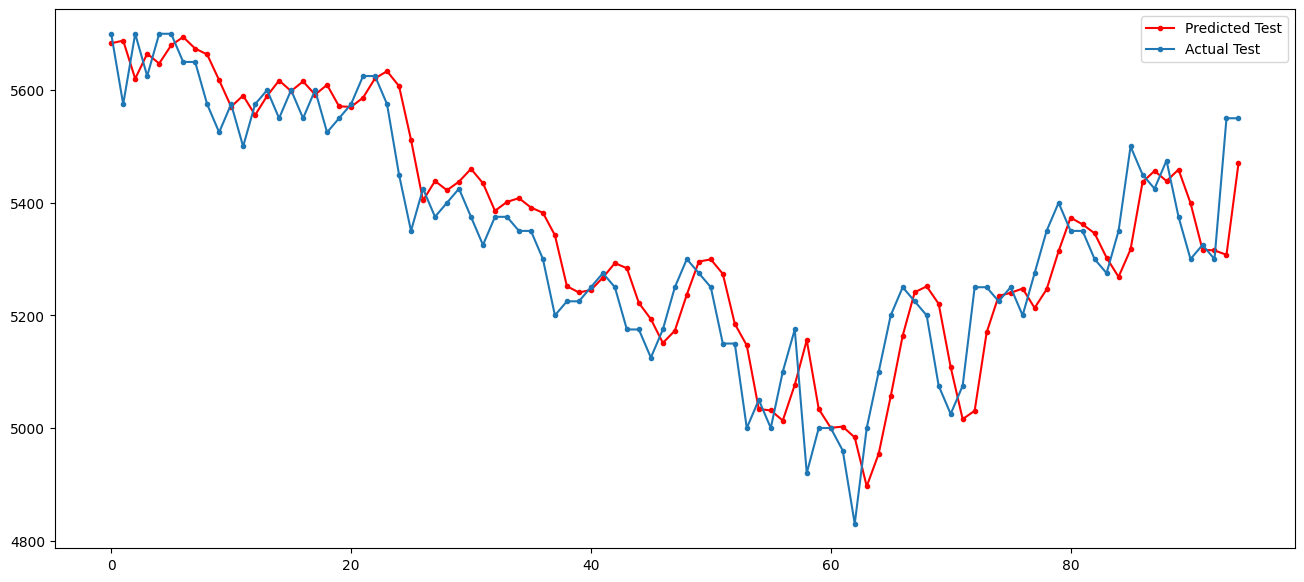

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 17ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5535.277344
1   2023-12-19     5548.919922
2   2023-12-20     5551.616699
3   2023-12-21     5549.051758
4   2023-12-22     5543.908203
5   2023-12-25     5538.552246
6   2023-12-26     5534.759277
7   2023-12-27     5533.547363
8   2023-12-28     5535.206055
9   2023-12-29     5539.537109
10  2024-01-01     5545.988281
11  2024-01-02     5553.839355
12  2024-01-03     5562.389648
13  2024-01-04     5570.997559
14  2024-01-05     5579.188965
15  2024-01-08     5586.675293
16  2024-01-09     5593.359375
17  2024-01-10     5599.251953
18  2024-01-11     5604.479004
19  2024-01-12     5609.200684
20  2024-01-15     5613.564941
21  2024-01-16     5617.692383


#Save Data

In [ ]:
predicted_df['Prediksi_Harga']=predicted_df['Prediksi_Harga'].round(decimals=0)

In [ ]:
predicted_df.to_csv('BRI.csv')

In [ ]:
test_data = close_prices[training_data_len:]
test_data

Date
2023-08-03    5700.0
2023-08-04    5575.0
2023-08-07    5700.0
2023-08-08    5625.0
2023-08-09    5700.0
               ...  
2023-12-11    5300.0
2023-12-12    5325.0
2023-12-13    5300.0
2023-12-14    5550.0
2023-12-15    5550.0
Name: Close, Length: 95, dtype: float64

In [ ]:
df_test_bri = pd.DataFrame(test_data)
df_test_bri['Testing'] = predictions.round(decimals=0)
df_test_bri

,Close,Testing
Date,,
2023-08-03,5700.0,5683.0
2023-08-04,5575.0,5688.0
2023-08-07,5700.0,5620.0
2023-08-08,5625.0,5665.0
2023-08-09,5700.0,5647.0
...,...,...
2023-12-11,5300.0,5399.0
2023-12-12,5325.0,5317.0
2023-12-13,5300.0,5315.0


In [ ]:
df_test_bri.to_csv('BRI_testing.csv')

In [ ]:
df_train_bri = close_prices[: training_data_len]
df_train_bri

Date
2022-01-03    4180.0
2022-01-04    4160.0
2022-01-05    4210.0
2022-01-06    4160.0
2022-01-07    4190.0
               ...  
2023-07-27    5650.0
2023-07-28    5700.0
2023-07-31    5650.0
2023-08-01    5700.0
2023-08-02    5700.0
Name: Close, Length: 382, dtype: float64

In [ ]:
df_train_bri.to_csv('BRI_train.csv')